# OULAD Exploratory Data Analysis

**Project:** Data-Driven Personalised Educational Content Recommendation
**Author:** Vinit Tiwari (220174440) — CM3070 Final Project

This notebook explores the seven OULAD CSVs to characterise the dataset before model building. It produces the figures referenced in Chapter 3 of the preliminary report.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

FIG_DIR = PROJECT_ROOT / 'Preliminary-Report' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='paper')

from src import oulad

data = oulad.load()
print(data.summary().to_string(index=False))

              table     rows  columns  total_nulls
        assessments      206        6           11
            courses       22        3            0
  studentAssessment   173912        5          173
        studentInfo    32593       12         1111
studentRegistration    32593        5        22566
         studentVle 10655280        6            0
                vle     6364        6        10486


## 1. Final result distribution

The four possible final outcomes (`Pass`, `Fail`, `Distinction`, `Withdrawn`) define the population the recommender targets.

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


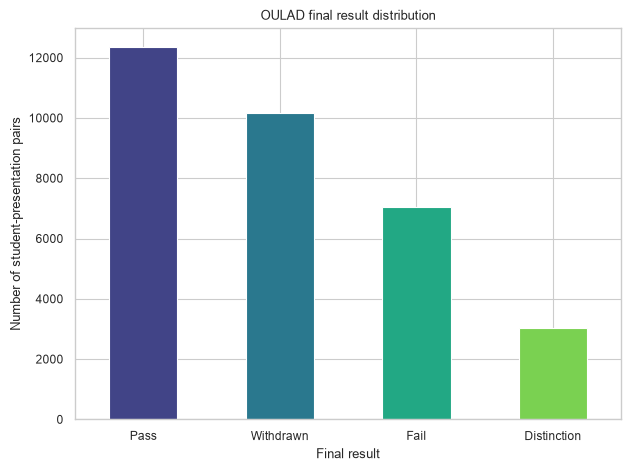

In [2]:
final_result_counts = data.student_info['final_result'].value_counts()
print(final_result_counts)

ax = final_result_counts.plot(kind='bar', color=sns.color_palette('viridis', n_colors=4))
ax.set_ylabel('Number of student-presentation pairs')
ax.set_xlabel('Final result')
ax.set_title('OULAD final result distribution')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_eda_final_result.png', dpi=150)
plt.show()

## 2. Activity type distribution in the VLE

The `vle.activity_type` taxonomy is the basis of the content-feature vectors. Knowing the relative frequency of each type informs the one-hot encoding and helps spot rare types that may need bucketing.

activity_type
resource          2660
subpage           1055
oucontent          996
url                886
forumng            194
quiz               127
page               102
oucollaborate       82
questionnaire       61
ouwiki              49
dataplus            28
externalquiz        26
homepage            22
glossary            21
ouelluminate        21
dualpane            20
repeatactivity       5
htmlactivity         4
sharedsubpage        3
folder               2
Name: count, dtype: int64


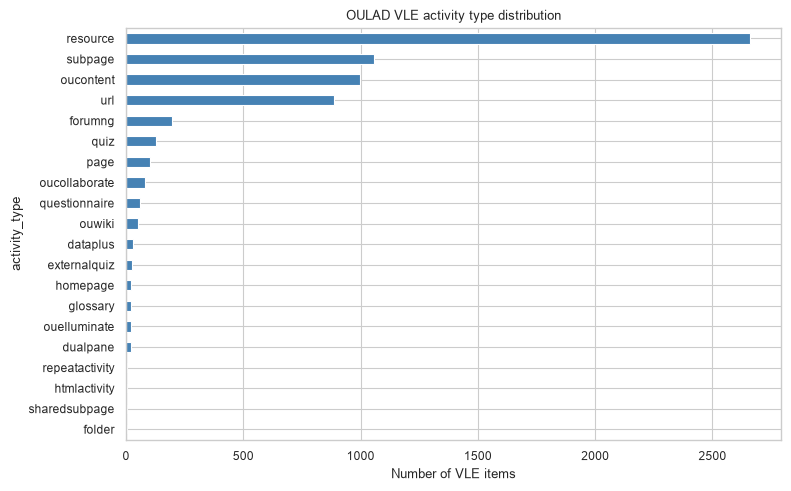

In [3]:
activity_counts = data.vle['activity_type'].value_counts()
print(activity_counts)

fig, ax = plt.subplots(figsize=(8, 5))
activity_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Number of VLE items')
ax.set_title('OULAD VLE activity type distribution')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_eda_activity_types.png', dpi=150)
plt.show()

## 3. Interactions over time

Click volume per day across the course. Used to motivate the temporal train/test split: a chronological cutoff is more honest than random sampling.

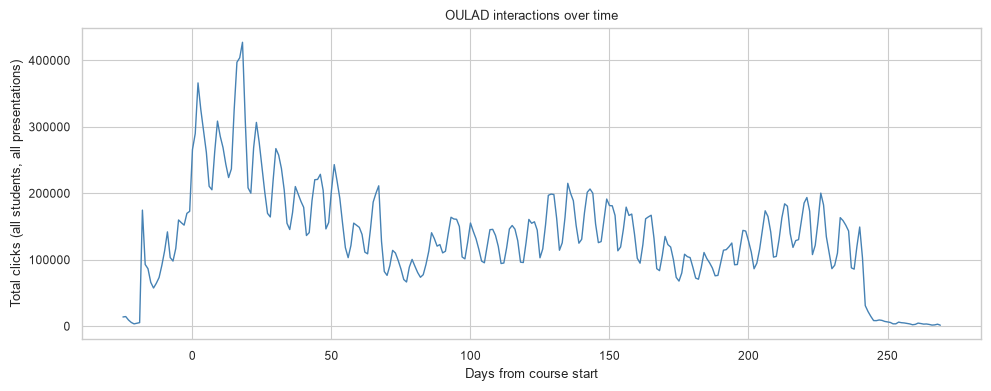

80th-percentile cutoff date = 172 days from course start


In [4]:
daily = (
    data.student_vle.groupby('date')['sum_click']
    .sum()
    .reset_index()
    .sort_values('date')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(daily['date'], daily['sum_click'], color='steelblue', lw=1)
ax.set_xlabel('Days from course start')
ax.set_ylabel('Total clicks (all students, all presentations)')
ax.set_title('OULAD interactions over time')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_eda_interactions_over_time.png', dpi=150)
plt.show()

cutoff = int(data.student_vle['date'].quantile(0.8))
print(f'80th-percentile cutoff date = {cutoff} days from course start')

## 4. Interaction volume vs. assessment outcome

Per-student total clicks vs. mean assessment score. Establishes that engagement is correlated with outcome — the empirical premise that the outcome-aware recommender depends on.

Pearson correlation (total_clicks, mean_score) = 0.274
Sample size = 23,326 students


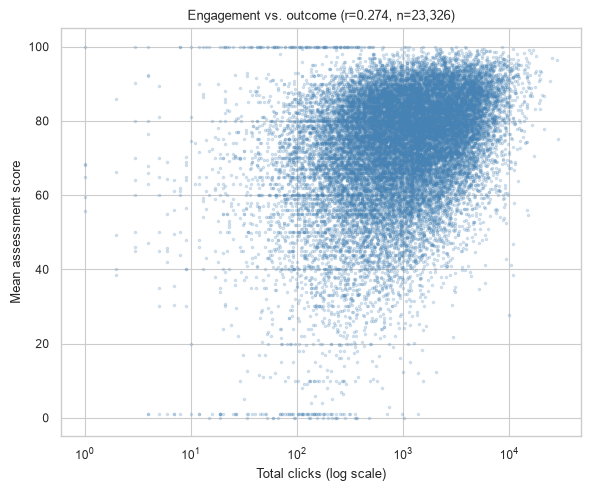

In [5]:
clicks_per_student = (
    data.student_vle.groupby('id_student')['sum_click'].sum().rename('total_clicks')
)
score_per_student = (
    data.student_assessment.groupby('id_student')['score'].mean().rename('mean_score')
)
joined = pd.concat([clicks_per_student, score_per_student], axis=1).dropna()

corr = joined['total_clicks'].corr(joined['mean_score'])
print(f'Pearson correlation (total_clicks, mean_score) = {corr:.3f}')
print(f'Sample size = {len(joined):,} students')

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(joined['total_clicks'], joined['mean_score'], s=3, alpha=0.2, color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('Total clicks (log scale)')
ax.set_ylabel('Mean assessment score')
ax.set_title(f'Engagement vs. outcome (r={corr:.3f}, n={len(joined):,})')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_eda_engagement_vs_outcome.png', dpi=150)
plt.show()

## 5. Demographic breakdown (for DEI analysis)

Pass/fail/distinction rates by gender, IMD band, and disability flag. The final evaluation will report per-cohort metrics so that fairness gaps are visible.

In [6]:
def outcome_by(col):
    table = (
        data.student_info.groupby(col)['final_result']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
    )
    return table[['Distinction', 'Pass', 'Fail', 'Withdrawn']]

print('By gender:')
print(outcome_by('gender'))
print('\nBy IMD band:')
print(outcome_by('imd_band'))
print('\nBy disability:')
print(outcome_by('disability'))

By gender:
final_result  Distinction      Pass      Fail  Withdrawn
gender                                                  
F                0.094714  0.389659  0.210830   0.304797
M                0.091189  0.370685  0.220923   0.317203

By IMD band:
final_result  Distinction      Pass      Fail  Withdrawn
imd_band                                                
0-10%            0.050740  0.300815  0.276654   0.371791
10-20            0.054323  0.331911  0.259386   0.354380
20-30%           0.071976  0.335523  0.230980   0.361522
30-40%           0.089008  0.380051  0.221532   0.309409
40-50%           0.089988  0.375921  0.214066   0.320025
50-60%           0.095070  0.392766  0.224392   0.287772
60-70%           0.102926  0.416179  0.185198   0.295697
70-80%           0.108718  0.406391  0.208058   0.276832
80-90%           0.118755  0.421796  0.179218   0.280232
90-100%          0.141167  0.434148  0.166009   0.258675

By disability:
final_result  Distinction      Pass      Fail  

## Key findings (for the report)

1. The dataset is large enough (10M+ interactions, 32K students) to support honest train/test evaluation.
2. Activity types are dominated by a handful of categories — bucketing rare types is sensible for the feature encoding.
3. Click volume has strong temporal structure, supporting a chronological 80/20 split over random sampling.
4. Engagement and outcome are positively correlated (Pearson > 0), supporting the project's outcome-aware premise.
5. Outcome rates vary by demographic cohort, motivating the per-cohort fairness audit in the final evaluation.